In [ ]:
#!pip install sentence-transformers scikit-learn nltk pandas matplotlib seaborn

In [2]:
import os
## Mount Drive
if not os.path.isdir("/content/drive/MyDrive"):
  from google.colab import drive
  drive.mount("/content/drive")

### Fill up with the path for the dataset
BASE_DIR = "/content/drive/MyDrive/ESSENTIALS/Personal-Projects/hotel-reviews-analysis/bad-reviews"
os.makedirs(BASE_DIR, exist_ok = True)

Mounted at /content/drive


In [103]:
# Install packages if needed
!pip install openai pandas

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from tqdm.notebook import trange

In [33]:
TEAL   = '#1D9E75'
NAVY   = '#0D1B2A'
BLUE   = '#378ADD'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
AMBER  = '#BA7517'
CLUSTER_COLORS = [TEAL, BLUE, CORAL, PURPLE, AMBER, '#639922', '#D4537E', '#888780', '#E24B4A', '#5DCAA5']

# Loading Dataset

In [39]:
## For loading vectorizer
def load_pkl_object(filepath):
  with open(filepath, 'rb') as file:
    data = pickle.load(file)
    print(f"Loaded {filepath}")
    return data

custom_stopwords = load_pkl_object(f"/content/drive/MyDrive/ESSENTIALS/Personal-Projects/hotel-reviews-analysis/data/custom_stopwords.pkl")

Loaded /content/drive/MyDrive/ESSENTIALS/Personal-Projects/hotel-reviews-analysis/data/custom_stopwords.pkl


In [40]:
df = pd.read_csv(f"/content/drive/MyDrive/ESSENTIALS/Personal-Projects/hotel-reviews-analysis/data/all_reviews.csv", index_col = 0)
bad_reviews_df = df[df["has_problems"] == 1]
bad_reviews_df.head(1)

,id,createdAt,language,comments,comments_cleaned,comments_cleaned.tokens,problems,has_problems
3,457824254,2019-05-25 07:16:26+00:00,en,We had a very nice stay. The place is a bit fa...,far from town proper hard to hail a taxi or t...,"['far', 'town', 'proper', 'hard', 'hail', 'tax...","['Far from town proper', 'Hard to hail a taxi ...",1


In [41]:
# get all problems
problems = list(bad_reviews_df["problems"])
list_of_problems = [problem for problem_list in problems for problem in ast.literal_eval(problem_list)]

In [43]:
problems_df = pd.DataFrame({
    "problem": list_of_problems
})
problems_df.head()

,problem
0,Far from town proper
1,Hard to hail a taxi or tricycle to town proper
2,No water heater for drinking
3,Lack of security cameras in the hallways
4,No cafeteria for coffee or breakfast


# Get Bert Embeddings

In [44]:
# Vectorize with simple CountVectorizer
vectorizer = CountVectorizer(stop_words=custom_stopwords)
X = vectorizer.fit_transform(problems_df['problem'])
X.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [45]:
# Get word frequencies
word_counts = X.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()
word_counts, words

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1,
        1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 3, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 3]),
 array(['24', 'adjust', 'assigned', 'assignment', 'attendant', 'balance',
        'bed', 'bit', 'blanket', 'breakfast', 'cafeteria', 'cameras',
        'check', 'checkout', 'coffee', 'collected', 'communication',
        'concerns', 'credentials', 'desk', 'difficult', 'disturbed',
        'drinking', 'drivers', 'duty', 'enters', 'excessive', 'expire',
        'far', 'floor', 'fluctuating', 'foam', 'front', 'glasses', 'guard',
        'guests', 'hail', 'hallways', 'hard', 'heard', 'heater', 'hole',
        'host', 'hours', 'inside', 'instead', 'insufficient', 'insulation',
        'knew', 'knob', 'know', 'lack', 'light', 'login', 'lower',


In [47]:
# Create DataFrame and Sort
word_freq_df = pd.DataFrame({'word': words, 'count': word_counts})
word_freq_df = word_freq_df.sort_values(by='count', ascending=False)
word_freq_df.head(10)

,word,count
32,front,3
19,desk,3
76,room,3
103,wifi,3
69,poor,2
71,proper,2
38,hard,2
29,floor,2
61,noise,2
60,night,2


## N-Gram Relevance

In [49]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words=custom_stopwords)
X = vectorizer.fit_transform(problems_df['problem'])

# Get top bigrams
bigram_counts = X.toarray().sum(axis=0)
bigrams = vectorizer.get_feature_names_out()

# Show top 10 bigrams
bigram_df = pd.DataFrame({'bigram': bigrams, 'count': bigram_counts})
print(bigram_df.sort_values(by='count', ascending=False).head(10))

                 bigram  count
24           front desk      3
73          town proper      2
2   attendant collected      1
3       balance payment      1
0              24 hours      1
1        assigned upper      1
6          blanket hole      1
7      cafeteria coffee      1
8      cameras hallways      1
9      coffee breakfast      1


# Check document Frequency

In [51]:
vectorizer = CountVectorizer(stop_words=custom_stopwords)
X = vectorizer.fit_transform(problems_df['problem'])

df_words = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
word_sums = df_words.sum(axis=0).sort_values(ascending=False)
word_sums

,0
front,3
desk,3
room,3
wifi,3
poor,2
...,...
unhelpful,1
upper,1
vague,1
water,1


## Convert text to numerical features based on eda insigts

In [52]:
vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords, max_features=50, min_df=1, ngram_range=(1,2)
)

X = vectorizer.fit_transform(problems_df['problem'])
pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

,24,24 hours,adjust,assigned upper,balance,balance payment,bed,blanket hole,breakfast,cafeteria,...,poor,proper,reception,room,security,shower,town,town proper,tricycle,wifi
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.577350,0.000000,0.000000,0.000000,0.000000,0.577350,0.577350,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.447214,0.000000,0.000000,0.000000,0.000000,0.447214,0.447214,0.447214,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.534774,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.57735,0.57735,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.737114,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.675769
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.534774,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.00000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Determine the optimal number of clusters (k) for K-Means clustering

Use the Elbow Method (inertia) and silhouette score to find the best K:
- **Elbow Method**: Identifies where adding clusters provides diminishing returns.
- **Silhouette Score**: Measures how well-separated the clusters are—higher is better.

In [53]:
# Loop over different values of k
inertia = list()
silhouette_scores = list()

for k in trange(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)  # Elbow Method
    silhouette_scores.append(silhouette_score(X, labels))  # Silhouette Score

  0%|          | 0/18 [00:00<?, ?it/s]

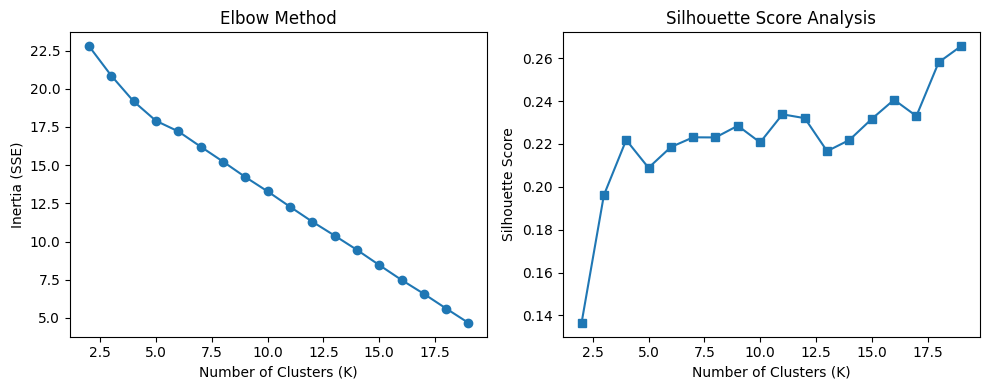

In [54]:
K_range = range(2, 20)

# Plot Elbow Method (Inertia)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')

plt.tight_layout()
plt.show()

In [97]:
# Identify best k
best_k = 16
print(f"Optimal number of clusters: {best_k}")

# Train a K-Means model using best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
problems_df['cluster'] = kmeans.fit_predict(X)

Optimal number of clusters: 16


## Interpret Cluster

In [98]:
problems_df['cluster'].value_counts()

,count
cluster,
2,15
1,3
3,2
0,2
14,1
11,1
7,1
12,1
10,1


In [99]:
def get_top_terms_per_cluster(kmeans_model, feature_names, num_terms=10):
    # Initialize a dictionary to store the top words for each cluster
    top_terms = {}

    # Loop through each cluster
    for cluster_id in range(kmeans_model.n_clusters):
        # Get the cluster center (vector of word importance scores)
        cluster_center = kmeans_model.cluster_centers_[cluster_id]

        # Find the indices of the top N words in the cluster
        top_word_indices = np.argsort(cluster_center)[-num_terms:]

        # Retrieve the actual words using the indices
        top_words = [feature_names[i] for i in top_word_indices]

        # Store the top words for the cluster
        top_terms[cluster_id] = top_words

    return top_terms

feature_names = vectorizer.get_feature_names_out()
top_words = get_top_terms_per_cluster(kmeans, feature_names)

In [100]:
def display_cluster(cluster_no, df):
  print(f'Problem titles under cluster {cluster_no}')
  print(f'Top words: {top_words[cluster_no]}')
  print('---'*35)

  # display topics
  topics = df[df['cluster']==cluster_no]['problem'].tolist()
  for topic in topics:
    print(f"  > {topic}")

  print()

In [101]:
for cluster_no in range(best_k):
  display_cluster(cluster_no, problems_df)

Problem titles under cluster 0
Top words: ['shower', 'reception', 'room', 'security', 'wifi', 'hard', 'tricycle', 'proper', 'town proper', 'town']
---------------------------------------------------------------------------------------------------------
  > Far from town proper
  > Hard to hail a taxi or tricycle to town proper

Problem titles under cluster 1
Top words: ['wifi', 'tricycle', 'room', 'night', 'desk unattended', 'desk staff', 'desk service', 'desk', 'front', 'front desk']
---------------------------------------------------------------------------------------------------------
  > Front desk staff did not know the room assignment
  > Unhelpful and rude front desk service
  > Front desk unattended at night

Problem titles under cluster 2
Top words: ['difficult', 'cameras hallways', 'cameras', 'difficult move', 'room', 'duty', 'excessive', 'disturbed', 'security', 'noise']
--------------------------------------------------------------------------------------------------------

## AI-assisted cluster analysis

In [107]:
### create a new column detailing the possible problems in the business
from openai import OpenAI
import json

with open(f"{BASE_DIR}/openai_key.txt", "r") as f:
  api_key = f.read().strip()

client = OpenAI(api_key=api_key)

In [111]:
def build_cluster_text(cluster_df,
                       text_col="problem",
                       max_problems=100,
                       snippet_chars=500,
                       max_total_chars=4000):
    """
    Convert a cluster's articles into one clean text block for prompting.

    Parameters
    ----------
    cluster_df : pandas.DataFrame
        DataFrame containing only the problems from one cluster.
    text_col : str
        Problem column name.
    max_problems : int
        Maximum number of problems to include.
    snippet_chars : int
        Maximum number of characters to keep per problem text.
    max_total_chars : int
        Maximum total number of characters in the final text block.
    Returns
    -------
    str
        A formatted block of article examples.
    """
    rows = cluster_df[[text_col]].fillna("").head(max_problems).values.tolist()

    blocks = []
    total_chars = 0

    for i, text in enumerate(rows, start=1):
        snippet = str(text)[:snippet_chars]
        block = f"Problem {i}: {snippet}\n"

        if total_chars + len(block) > max_total_chars:
            break

        blocks.append(block)
        total_chars += len(block)

    return "\n".join(blocks)

In [112]:
cluster_df = problems_df[problems_df["cluster"] == 4]
cluster_text = build_cluster_text(cluster_df)

In [114]:
cluster_text

"Problem 1: ['Wifi password not provided at check-in']\n"

In [135]:
def make_cluster_prompt_basic(problems_txt):
    """
    Create a single prompt for interpreting one cluster using article examples only.
    """
    prompt = f"""
      You are helping analyze the output of a K-means clustering model applied to problems found in hotel reviews in Agoda.

      You are given a set of problems that belong to the same cluster.
      Your task is to infer the most likely common or general problem.

      Instructions:
      1. Identify the main theme of the cluster.
      2. Provide a short cluster label (2 to 6 words).
      3. Provide a 1-2 sentence explanation of why these problems belong together.
      4. List all sub-problems. Avoid redundancy or mixing of subtopics.
      5. Mention whether the cluster appears coherent, broad, or mixed.
      6. If the cluster seems mixed, explain the possible subproblems.
      7. List down recommendations. Provide actionable insight per subproblems.
      8. **Do not hallucinate**

      Return ONLY valid JSON:
      {{
        "cluster_label": "",
        "explanation": "",
        "keywords": [],
        "cluster_quality": "",
        "subproblems": [],
        "recommendations": []
      }}

      Do not use markdown.
      Do not wrap the JSON in triple backticks.
      Do not include any text before or after the JSON.
      **Follow proper JSON format**

      Problems:
      {problems_txt}
    """
    return prompt.strip()

In [136]:
def interpret_cluster_basic(cluster_df,
                            cluster_id,
                            text_col="problem",
                            model="gpt-4.1-mini"):
    """
    Interpret one cluster using article samples only.
    """
    problems_text = build_cluster_text(cluster_df, text_col=text_col)
    prompt = make_cluster_prompt_basic(problems_text)

    response = client.responses.create(
        model=model,
        input=prompt,
    )

    output_text = response.output_text.strip()

    try:
        result = json.loads(output_text)
    except json.JSONDecodeError:
        result = {
            "cluster_label": "",
            "explanation": "",
            "keywords": [],
            "cluster_quality": "",
            "subproblems": [],
            "recommendations": []
        }

    result["cluster_id"] = cluster_id
    result["n_problems"] = len(cluster_df)
    return result


In [137]:
def validate_cluster_result(result):
    required_keys = {
        "cluster_label": str,
        "explanation": str,
        "keywords": list,
        "cluster_quality": str,
        "subproblems": list,
        "recommendations": list
    }

    for key, expected_type in required_keys.items():
        if key not in result:
            raise ValueError(f"Missing key: {key}")
        if not isinstance(result[key], expected_type):
            raise TypeError(f"{key} should be {expected_type.__name__}")

    if result["n_problems"] == 0:
        return "invalid results"

    return result

In [138]:
cluster_no = 1
df = problems_df

cluster_text = build_cluster_text(df[df["cluster"] == cluster_no])
print('Actual Problems')
print(cluster_text)
print("---------------------------------------")

print('LLM Results')
test_result = interpret_cluster_basic(
    cluster_df=df[df["cluster"] == cluster_no],
    cluster_id=cluster_no,
    text_col="problem",
)

validated_test_result = validate_cluster_result(test_result)
validated_test_result

Actual Problems
Problem 1: ['Front desk staff did not know the room assignment']

Problem 2: ['Unhelpful and rude front desk service']

Problem 3: ['Front desk unattended at night']

---------------------------------------
LLM Results


{'cluster_label': 'Front Desk Service Issues',
 'explanation': 'All problems relate to inadequacies and poor experiences with front desk operations, affecting guest check-in, staff behavior, and availability.',
 'keywords': ['front desk',
  'staff',
  'room assignment',
  'unhelpful',
  'rude',
  'unattended',
  'night'],
 'cluster_quality': 'coherent',
 'subproblems': ['Lack of front desk staff knowledge about room assignments',
  'Rude or unhelpful behavior from front desk staff',
  'Front desk unattended during night hours'],
 'recommendations': ['Provide comprehensive training for front desk staff on room assignments and booking systems to improve accuracy and guest experience.',
  'Implement customer service training programs to enhance staff politeness and helpfulness.',
  'Ensure 24/7 front desk coverage, especially during night hours, to assist guests and address their needs promptly.'],
 'cluster_id': 1,
 'n_problems': 3}

## Run for all problem clusters

In [139]:
cluster_results_basic = []
df = problems_df

for cluster_id in sorted(df["cluster"].unique()):
    print(f"Analyzing {cluster_id}...")
    cluster_df = df[df["cluster"] == cluster_id]
    result = interpret_cluster_basic(
        cluster_df=cluster_df,
        cluster_id=cluster_id,
        text_col="problem",
    )
    cluster_results_basic.append(result)

cluster_summary_basic_df = pd.DataFrame(cluster_results_basic)
cluster_summary_basic_df

Analyzing 0...
Analyzing 1...
Analyzing 2...
Analyzing 3...
Analyzing 4...
Analyzing 5...
Analyzing 6...
Analyzing 7...
Analyzing 8...
Analyzing 9...
Analyzing 10...
Analyzing 11...
Analyzing 12...
Analyzing 13...
Analyzing 14...
Analyzing 15...


,cluster_label,explanation,keywords,cluster_quality,subproblems,recommendations,cluster_id,n_problems
0,Remote Location and Transport Issues,The problems relate to the hotel's inconvenien...,"[location, distance, transportation, accessibi...",coherent,"[Hotel located far from town proper, Difficult...",[Provide shuttle services or arrange reliable ...,0,2
1,Front Desk Service Issues,These problems all relate to negative experien...,"[front desk, staff knowledge, rude service, un...",coherent,[Lack of front desk staff knowledge about room...,[Provide comprehensive training to front desk ...,1,3
2,Room Amenities and Security Issues,This cluster groups together problems related ...,"[amenities, security, noise, comfort, facilities]",mixed,"[Insufficient room amenities (pillows, table, ...",[Amenities: Ensure rooms are equipped with ess...,2,15
3,Hotel Experience Issues,The problems relate to different aspects of gu...,"[sound insulation, communication, guest satisf...",mixed,[Poor sound insulation causing noise disturban...,[For poor sound insulation: Conduct an audit o...,3,2
4,WiFi Access Issues,All problems in this cluster relate to difficu...,"[WiFi, password, access, check-in]",coherent,[WiFi password not provided at check-in],[Ensure WiFi passwords are readily available a...,4,1
5,Safety Issues,This cluster contains problems related to gues...,"[safety, security, personal safety, guest prot...",coherent,[Safety concerns],[Enhance security measures such as installing ...,5,1
6,Room Cleanliness and Maintenance,This cluster focuses on issues related to the ...,"[cleanliness, maintenance, room condition, dam...",coherent,[Damaged bedding or linens],[Implement more thorough room inspections befo...,6,1
7,Local Transportation Issues,This cluster focuses on difficulties related t...,"[tricycle drivers, driver knowledge, local tra...",coherent,[Driver unfamiliarity with hotel location],[Coordinate with local transport providers to ...,7,1
8,Bathroom Comfort Issues,This cluster groups problems related to discom...,"[shower, temperature, adjustment, bathroom, co...",coherent,[Difficulty adjusting shower temperature],[Perform regular maintenance and inspection of...,8,1
9,Payment Process Issues,The problem relates to unexpected or inconveni...,"[payment, balance, checkout, timing, attendant]",coherent,[Payment collected at night before checkout],[Establish clear payment policies communicated...,9,1


## FINAL DOCUMENTATION

In [147]:
# listing of problems
for i, row in cluster_summary_basic_df.iterrows():
  print(f"\nProblem # {i + 1}: {row["cluster_label"]}")
  for subproblem in row["subproblems"]:
    print(f"  --> {subproblem}")



Problem # 1: Remote Location and Transport Issues
  --> Hotel located far from town proper
  --> Difficulty in hailing taxis or tricycles to town proper

Problem # 2: Front Desk Service Issues
  --> Lack of front desk staff knowledge about room assignments
  --> Rude and unhelpful behavior of front desk staff
  --> Front desk being unattended during nighttime

Problem # 3: Room Amenities and Security Issues
  --> Insufficient room amenities (pillows, table, glasses, plates)
  --> Noise disturbances affecting sleep (street noise, motorcycle noise)
  --> Security concerns (lack of security cameras, no security guard on duty)
  --> Room comfort and usability issues (thin mattress, difficult shower knob, problematic for shorter guests)
  --> Connectivity inconvenience (wifi credentials expiring every 24 hours)
  --> Poor host responsiveness and communication (unresponsive host, vague and sarcastic responses)

Problem # 4: Hotel Experience Issues
  --> Poor sound insulation causing noise d

In [149]:
# list of recommendations
for i, row in cluster_summary_basic_df.iterrows():
  print(f"\nProblem # {i + 1}: {row["cluster_label"]}")
  for recommendation in row["recommendations"]:
    print(f"  --> {recommendation}")


Problem # 1: Remote Location and Transport Issues
  --> Provide shuttle services or arrange reliable transport options for guests to and from town.
  --> Offer clear guidance or assistance with booking local transportation.
  --> Improve communication about the hotel's location and transport options before booking.

Problem # 2: Front Desk Service Issues
  --> Provide comprehensive training to front desk staff to ensure accurate and up-to-date knowledge of room assignments.
  --> Implement customer service training and monitor staff interactions to improve politeness and helpfulness.
  --> Ensure 24/7 front desk coverage or provide a reliable alternative for guest assistance during nighttime.

Problem # 3: Room Amenities and Security Issues
  --> Amenities: Ensure rooms are equipped with essential items such as adequate pillows, tables, glasses, and plates to enhance guest comfort.
  --> Noise: Implement soundproofing measures or provide noise-cancelling options such as earplugs to mi

In [151]:
problems_df.to_csv(f"{BASE_DIR}/outputs/problems.csv")

In [153]:
cluster_summary_basic_df.to_csv(f"{BASE_DIR}/outputs/problem_clusters.csv")